In [7]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import os

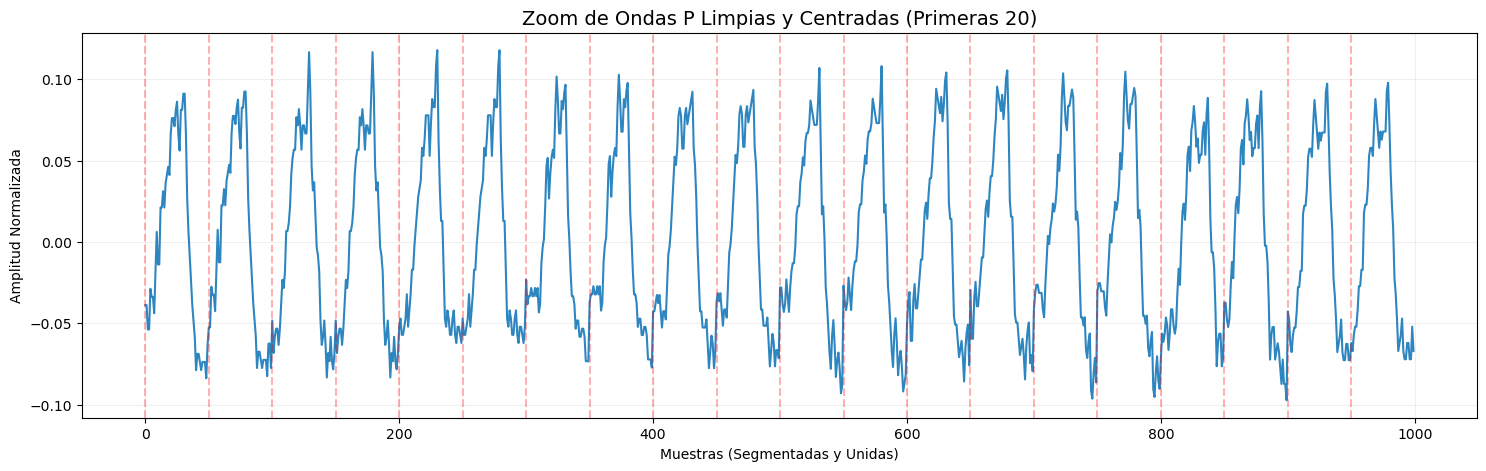

¡Dataset generado! Ahora las ondas están centradas y son legibles en: C:\Users\PC\Desktop\IA_AIFB\data\processed\ondas_p_limpias


In [ ]:
path_base = r'C:\Users\PC\Desktop\IA_AIFB\data\raw\QT'
nombre_registro = 'sel100'
ruta_registro = os.path.join(path_base, nombre_registro)

try:
    record = wfdb.rdrecord(ruta_registro)
    annotation = wfdb.rdann(ruta_registro, 'pu')
    signal = record.p_signal[:, 0]

    # 1. Filtrar picos P
    picos_p = [annotation.sample[i] for i, sym in enumerate(annotation.symbol) if sym == 'p']
    
    # 2. Extraer segmentos y NORMALIZAR (Centrar en 0)
    ancho = 25
    ondas_p_limpias = []

    for p in picos_p:
        if p > ancho and p < len(signal) - ancho:
            segmento = signal[p - ancho : p + ancho]
            # Restamos la media del segmento para que la onda P no esté "volando" en 4.8mV
            segmento_centrado = segmento - np.mean(segmento)
            ondas_p_limpias.append(segmento_centrado)

    # 3. Graficar solo las primeras 20 ondas para que sean LEGIBLES
    cantidad_a_mostrar = 20     # Si coloco una cantidad mayor no se va a entender nada, así que lo dejamos así.
    solo_p_concatenadas = np.concatenate(ondas_p_limpias[:cantidad_a_mostrar])

    plt.figure(figsize=(18, 5), facecolor='white')
    plt.plot(solo_p_concatenadas, color='#2E86C1', linewidth=1.5)
    
    # Añadir líneas verticales para separar cada onda y que veas el recorte
    for i in range(cantidad_a_mostrar):
        plt.axvline(x=i * (ancho * 2), color='red', linestyle='--', alpha=0.3)

    plt.title(f"Zoom de Ondas P Limpias y Centradas (Primeras {cantidad_a_mostrar})", fontsize=14)
    plt.grid(True, alpha=0.2)
    plt.ylabel("Amplitud Normalizada")
    plt.xlabel("Muestras (Segmentadas y Unidas)")
    plt.show()

    # 4. Guardar para tu dataset (Imágenes individuales legibles)
    output_folder = r'C:\Users\PC\Desktop\IA_AIFB\data\processed\ondas_p_limpias'
    if not os.path.exists(output_folder): os.makedirs(output_folder)

    for i, segmento in enumerate(ondas_p_limpias):
        plt.figure(figsize=(1.5, 1.5))
        plt.plot(segmento, color='black')
        plt.axis('off')
        plt.savefig(os.path.join(output_folder, f"onda_p_{i:03d}.png"))
        plt.close()

    print(f"¡Dataset generado! Ahora las ondas están centradas y son legibles en: {output_folder}")
    os.startfile(output_folder)

except Exception as e:
    print(f"Error: {e}")